In [3]:
import csv
import numpy as np
import matplotlib.pyplot as plt

def plot_nll_distribution(csv_path: str, dataset_name: str = "Dataset"):
    bin_starts = []
    bin_ends = []
    counts = []
    
    # 1. Read the pre-binned data
    with open(csv_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            bin_starts.append(float(row['bin_start']))
            bin_ends.append(float(row['bin_end']))
            counts.append(int(float(row['count'])))
            
    bin_starts = np.array(bin_starts)
    bin_ends = np.array(bin_ends)
    counts = np.array(counts)
    
    # Check if data is empty
    if len(counts) == 0:
        print(f"Error: {csv_path} is empty.")
        return

    bin_width = bin_ends[0] - bin_starts[0]
    
    # 2. Calculate the CDF
    cumulative_counts = np.cumsum(counts)
    total_tokens = cumulative_counts[-1]
    cdf = cumulative_counts / total_tokens
    
    # 3. Create the plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Plot 1: Histogram (Density) ---
    ax1.bar(bin_starts, counts, width=bin_width, align='edge', color='#4C72B0', edgecolor='none')
    ax1.set_title(f'{dataset_name} - Token NLL Histogram', fontsize=14)
    ax1.set_xlabel('Negative Log-Likelihood (NLL)', fontsize=12)
    ax1.set_ylabel('Token Count', fontsize=12)
    ax1.set_xlim(0, max(bin_ends))
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # --- Plot 2: Cumulative Distribution Function (CDF) ---
    # We plot the CDF against the *end* of each bin to accurately represent cumulative probability
    x_cdf = np.insert(bin_ends, 0, bin_starts[0])
    y_cdf = np.insert(cdf, 0, 0.0)
    
    ax2.plot(x_cdf, y_cdf, color='#C44E52', linewidth=2)
    ax2.fill_between(x_cdf, y_cdf, alpha=0.2, color='#C44E52')
    ax2.set_title(f'{dataset_name} - Token NLL CDF', fontsize=14)
    ax2.set_xlabel('Negative Log-Likelihood (NLL)', fontsize=12)
    ax2.set_ylabel('Cumulative Probability (0 to 1)', fontsize=12)
    ax2.set_xlim(0, max(bin_ends))
    ax2.set_ylim(0, 1.05)
    
    # Add horizontal lines for common percentiles (90%, 95%, 99%)
    for percent in [0.90, 0.95, 0.99]:
        ax2.axhline(y=percent, color='gray', linestyle=':', alpha=0.8)
        ax2.text(0.5, percent + 0.01, f'{int(percent*100)}th Percentile', color='gray', fontsize=9)
        
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Example usage:
# plot_nll_distribution("wikitext2_token_nll_hist.csv", "WikiText-2")

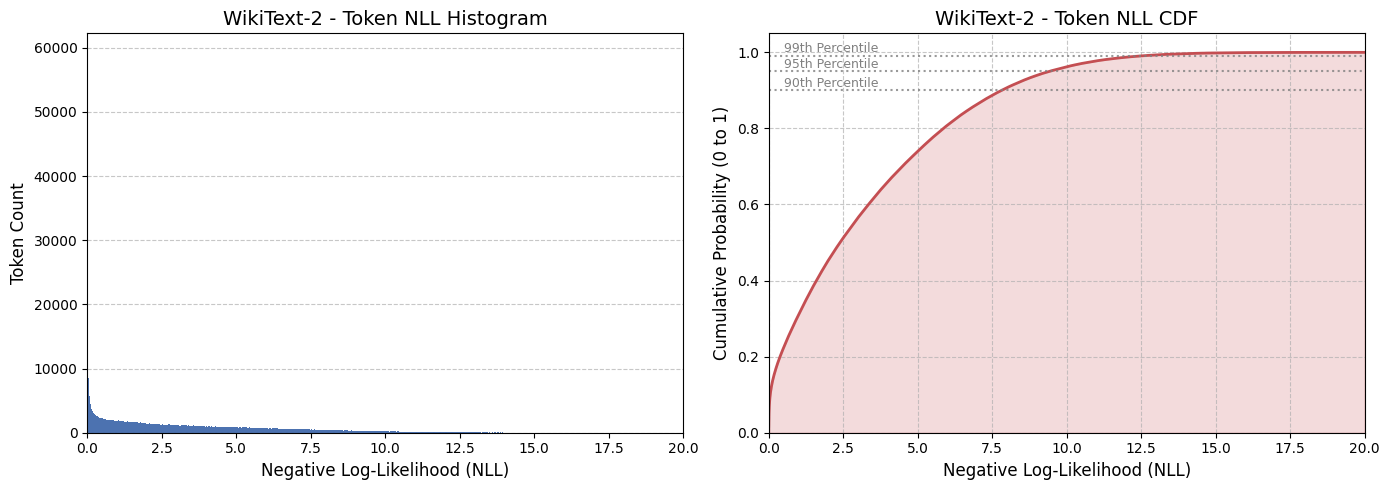

In [4]:
plot_nll_distribution("wikitext2_token_nll_hist.csv", "WikiText-2")

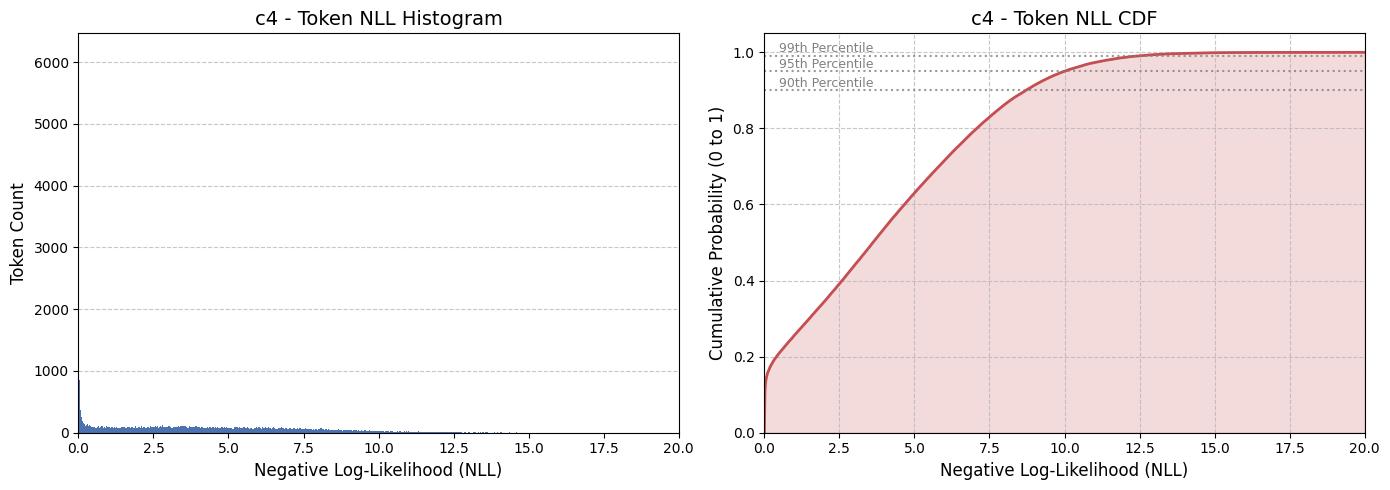

In [6]:
plot_nll_distribution("ptb_opt_token_nll_hist-20260309_232835.csv", "c4")